# Sensitivity Analysis for Roundabout Policy

**Textbook Section 11.3.1 — Sensitivity Analysis** (Algorithm 11.1), adapted
for scenario-level parameters.

Perturb one `ScenarioParams` field at a time while holding all others at
nominal, run rollouts at each value, and measure the effect on **robustness**
and **failure rate**. Parameters with high sensitivity are the ones most
responsible for failures.

In [2]:
import os
os.environ["SDL_VIDEODRIVER"] = "dummy"

import copy
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import DQN

from src import (
    ScenarioParams,
    GaussianMixtureParam,
    NormalParam,
    ProbabilityParam,
    BetaParam,
    NOMINAL,
    SQRT_2,
    SimulatedEnv,
    ScenarioFuzzer,
    FuzzerConfig,
    compute_robustness,
    weights_from_vector,
)

In [3]:
env = gym.make("SimulatedEnv-v0", render_mode=None, scenario_params=copy.deepcopy(NOMINAL))
obs, info = env.reset()

model = DQN.load("roundabout_dqn/best_model/best_model.zip", env=env, device="cpu")

env.unwrapped.config["simulation_frequency"] = 15
env.unwrapped.config.update({
    "observation": {
        "type": "Kinematics",
        "absolute": True,
        "features_range": {
            "x": [-100, 100],
            "y": [-100, 100],
            "vx": [-15, 15],
            "vy": [-15, 15],
        },
        "vehicles_count": 5,
    },
})

robustness_weights = weights_from_vector([0.2042, 0.1982, 0.4393, 0.0111, 0.1471])

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [4]:
def sensitivity_sweep(name, setter_fn, values, model, robustness_weights,
                      n_rollouts=30, seed=42):
    """One-at-a-time sensitivity sweep (Algorithm 11.1 adapted).

    For each value in *values*, deepcopy NOMINAL, apply *setter_fn* to change
    one parameter, run *n_rollouts* rollouts, and collect robustness stats.

    Args:
        name: Human-readable parameter name (for printing).
        setter_fn: Callable(params, value) that mutates params in place.
        values: List of parameter values to sweep.
        model: Trained DQN model for rollouts.
        robustness_weights: Weights dict for compute_robustness.
        n_rollouts: Rollouts per sweep point.
        seed: RNG seed for reproducibility.

    Returns:
        Dict with arrays: values, mean_robustness, std_robustness,
        failure_rate, all_robustness (list of arrays per value).
    """
    mean_rob = []
    std_rob = []
    fail_rate = []
    all_rob = []

    for i, v in enumerate(values):
        params = copy.deepcopy(NOMINAL)
        setter_fn(params, v)

        env_s = gym.make("SimulatedEnv-v0", render_mode=None, scenario_params=params)
        env_s.reset()
        fuzzer_s = ScenarioFuzzer(
            env_s, model,
            scenario_params=params,
            robustness_weights=robustness_weights,
            config=FuzzerConfig(verbose=False),
            seed=seed,
        )

        robs = []
        n_fail = 0
        for _ in range(n_rollouts):
            r = fuzzer_s.rollout(compute_log_prob=False)
            robs.append(r["robustness"])
            if r["is_failure"]:
                n_fail += 1

        env_s.close()

        robs = np.array(robs)
        mean_rob.append(float(np.mean(robs)))
        std_rob.append(float(np.std(robs)))
        fail_rate.append(n_fail / n_rollouts)
        all_rob.append(robs)

        print(f"  {name}={v:>8.2f}  |  robustness={mean_rob[-1]:.3f} ± {std_rob[-1]:.3f}"
              f"  |  fail={fail_rate[-1]:.1%}")

    return {
        "name": name,
        "values": np.array(values, dtype=float),
        "mean_robustness": np.array(mean_rob),
        "std_robustness": np.array(std_rob),
        "failure_rate": np.array(fail_rate),
        "all_robustness": all_rob,
    }

In [5]:
N_ROLLOUTS = 30

sweep_configs = [
    (
        "entering_vehicle_mu",
        lambda p, v: setattr(p.entering_vehicle_position, "mu", [v, v]),
        [5, 20, 40, 60, 80, 100, 120, 140],
    ),
    (
        "other_vehicle_speed",
        lambda p, v: setattr(p.other_vehicle_speed, "mu", v),
        [10, 13, 16, 19, 22, 25],
    ),
    (
        "ctrl_noise_p",
        lambda p, v: setattr(p.high_lvl_ctrl_noise, "p", [v]),
        [0.0, 0.05, 0.1, 0.2, 0.3, 0.5],
    ),
    (
        "initial_speed_mu",
        lambda p, v: setattr(p.initial_speed, "mu", v),
        [0, 4, 8, 12, 16],
    ),
]

results = {}
for name, setter, values in sweep_configs:
    print(f"\n── Sweeping {name} ──")
    results[name] = sensitivity_sweep(
        name, setter, values, model, robustness_weights, n_rollouts=N_ROLLOUTS,
    )


── Sweeping entering_vehicle_mu ──
  entering_vehicle_mu=    5.00  |  robustness=0.745 ± 0.222  |  fail=6.7%
  entering_vehicle_mu=   20.00  |  robustness=0.767 ± 0.221  |  fail=6.7%
  entering_vehicle_mu=   40.00  |  robustness=0.734 ± 0.255  |  fail=10.0%
  entering_vehicle_mu=   60.00  |  robustness=0.739 ± 0.255  |  fail=10.0%
  entering_vehicle_mu=   80.00  |  robustness=0.431 ± 0.405  |  fail=46.7%
  entering_vehicle_mu=  100.00  |  robustness=0.688 ± 0.316  |  fail=16.7%
  entering_vehicle_mu=  120.00  |  robustness=0.619 ± 0.376  |  fail=26.7%
  entering_vehicle_mu=  140.00  |  robustness=0.709 ± 0.320  |  fail=16.7%

── Sweeping other_vehicle_speed ──
  other_vehicle_speed=   10.00  |  robustness=0.282 ± 0.370  |  fail=63.3%
  other_vehicle_speed=   13.00  |  robustness=0.568 ± 0.377  |  fail=30.0%
  other_vehicle_speed=   16.00  |  robustness=0.745 ± 0.222  |  fail=6.7%
  other_vehicle_speed=   19.00  |  robustness=0.694 ± 0.259  |  fail=10.0%
  other_vehicle_speed=   22.00 

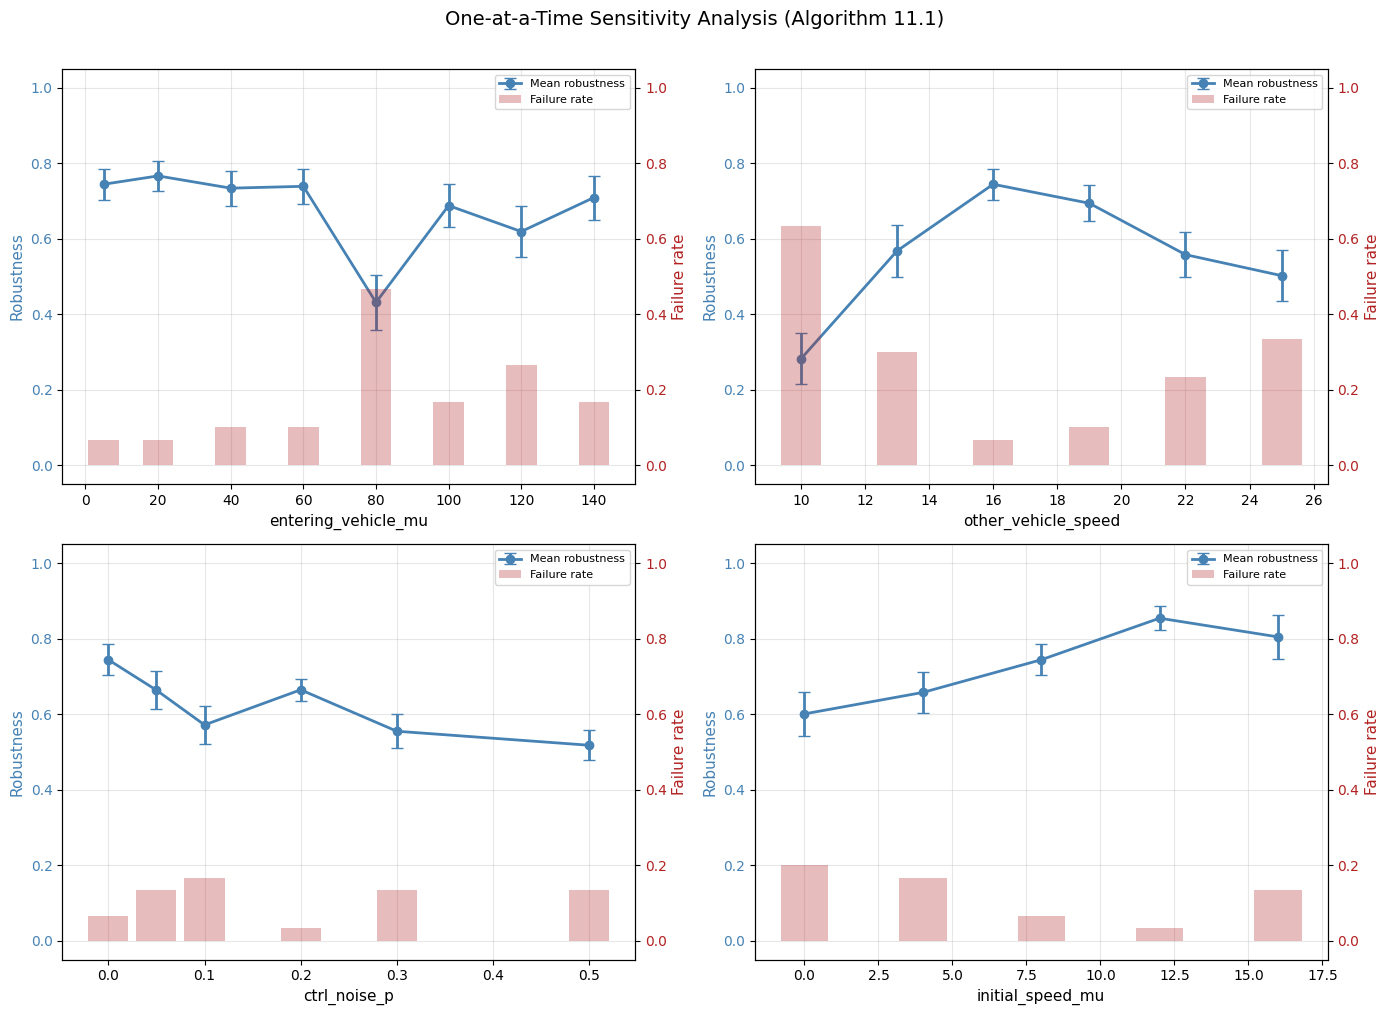

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (name, res) in zip(axes.flat, results.items()):
    vals = res["values"]
    mr = res["mean_robustness"]
    sr = res["std_robustness"]
    fr = res["failure_rate"]

    color_rob = "steelblue"
    color_fail = "firebrick"

    ax.errorbar(vals, mr, yerr=sr / np.sqrt(N_ROLLOUTS), fmt="o-",
                color=color_rob, linewidth=2, capsize=4, label="Mean robustness")
    ax.set_xlabel(name, fontsize=11)
    ax.set_ylabel("Robustness", color=color_rob, fontsize=11)
    ax.tick_params(axis="y", labelcolor=color_rob)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)

    ax2 = ax.twinx()
    ax2.bar(vals, fr, width=(vals[-1] - vals[0]) / len(vals) * 0.5,
            alpha=0.3, color=color_fail, label="Failure rate")
    ax2.set_ylabel("Failure rate", color=color_fail, fontsize=11)
    ax2.tick_params(axis="y", labelcolor=color_fail)
    ax2.set_ylim(-0.05, 1.05)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=8)

fig.suptitle("One-at-a-Time Sensitivity Analysis (Algorithm 11.1)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

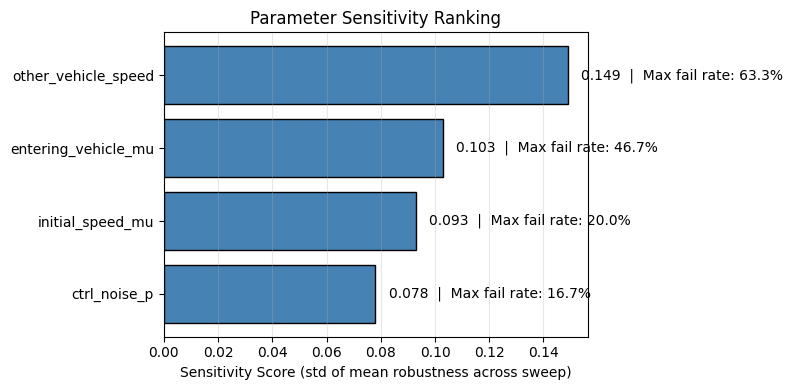

In [10]:
sensitivity_scores = {}
max_failures = {}
for name, res in results.items():
    sensitivity_scores[name] = float(np.std(res["mean_robustness"]))
    max_failures[name] = float(np.max(res["failure_rate"]))

ranked = sorted(sensitivity_scores.items(), key=lambda x: x[1], reverse=True)
names_ranked = [r[0] for r in ranked]
scores_ranked = [r[1] for r in ranked]
failures_ranked = [max_failures[name] for name in names_ranked]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(names_ranked[::-1], scores_ranked[::-1], color="steelblue", edgecolor="black")
ax.set_xlabel("Sensitivity Score (std of mean robustness across sweep)")
ax.set_title("Parameter Sensitivity Ranking")
ax.grid(True, axis="x", alpha=0.3)

for bar, score, max_fail in zip(bars, scores_ranked[::-1], failures_ranked[::-1]):
    ax.text(
        bar.get_width() + 0.005, 
        bar.get_y() + bar.get_height() / 2,
        f"{score:.3f}  |  Max fail rate: {max_fail:.1%}", 
        va="center", fontsize=10
    )

plt.tight_layout()
plt.show()

In [8]:
print(f"{'Rank':<6} {'Parameter':<25} {'Sensitivity':>12}  {'Max Fail Rate':>14}")
print("─" * 60)
for rank, (name, score) in enumerate(ranked, 1):
    max_fr = float(np.max(results[name]["failure_rate"]))
    print(f"{rank:<6} {name:<25} {score:>12.4f}  {max_fr:>13.1%}")

env.close()

Rank   Parameter                  Sensitivity   Max Fail Rate
────────────────────────────────────────────────────────────
1      other_vehicle_speed             0.1489          63.3%
2      entering_vehicle_mu             0.1028          46.7%
3      initial_speed_mu                0.0929          20.0%
4      ctrl_noise_p                    0.0779          16.7%
